In [ ]:
# Feature Maps - results after applying filter through the pixel value of the image
# Filters & Kernels - weights learned using backpropagation

In [29]:
import torch
from torchvision import models, transforms
import matplotlib.pyplot as plt
from PIL import  Image
%matplotlib inline

In [34]:
transform = transforms.Compose([transforms.Resize((224, 224)),transforms.ToTensor(),transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])])
image = Image.open(r"/home/s_ach/Desktop/EyePACS-DEV-RG-1.jpg")
# plt.imshow(image)
# plt.show()
vgg= models.vgg16(weights='DEFAULT')
vgg.classifier[-1] #vgg.classifier[6]
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
vgg = vgg.to(device)
image = transform(image)
image = image.unsqueeze(0) # Adding batch size
image = image.to(device)
image.shape


torch.Size([1, 3, 224, 224])

In [35]:
model_list = list(vgg.features.modules())
# Process image to every layer and append output and name of the layer to outputs[] and names[] lists
outputs = []
names = []
for layer in model_list[1:]:
  image = layer(image)
  outputs.append(image)
  names.append(str(layer))

In [36]:
# len(outputs)
# Print feature maps
# for feature_map in outputs:
#     print(feature_map.shape)

In [37]:
processed = []
for feature_map in outputs:
  feature_map = feature_map.squeeze(0)
  #Convert 3D tensor to 2D, Sum the same element of every channel
  gray_scale = torch.sum(feature_map, 0)
  gray_scale = gray_scale / feature_map.shape[0]
  processed.append(gray_scale.data.cpu().numpy())

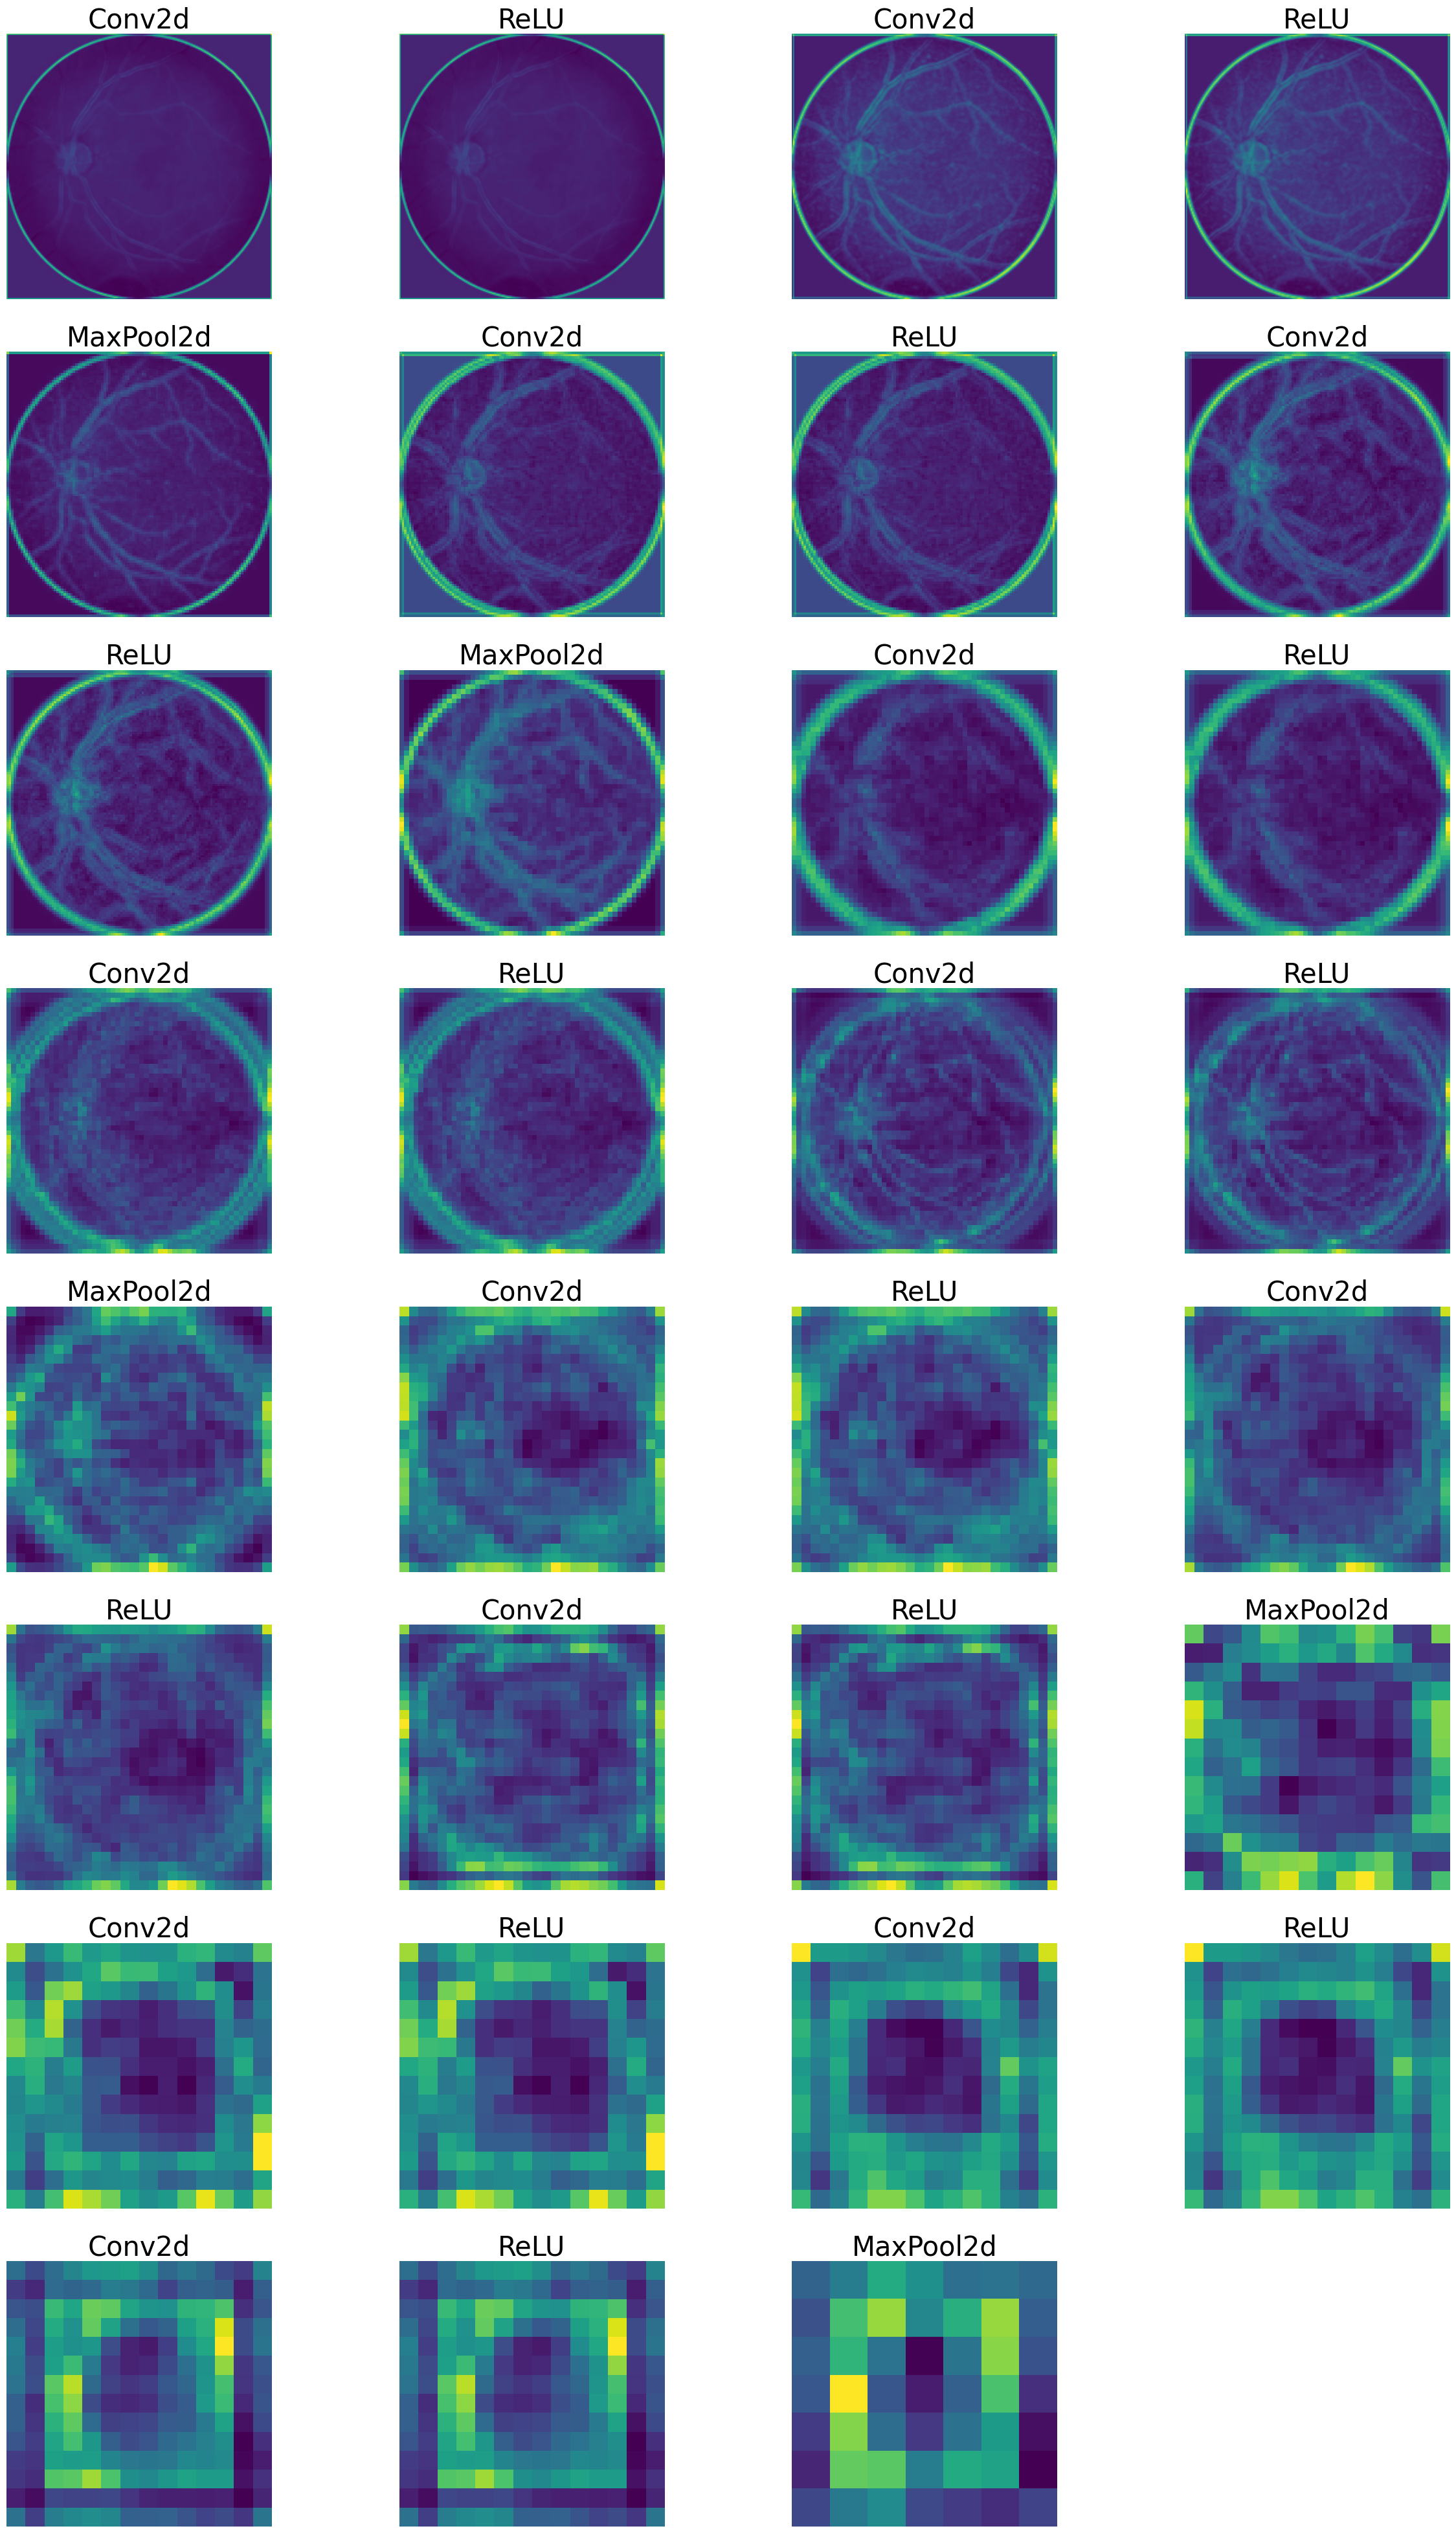

In [38]:
# Plotting feature maps and save
fig = plt.figure(figsize=(30, 50))
for i in range(len(processed)):
    a = fig.add_subplot(8, 4, i+1)
    imgplot = plt.imshow(processed[i])
    a.axis("off")
    a.set_title(names[i].split('(')[0], fontsize=30)
plt.savefig(str('feature_maps.jpg'), bbox_inches='tight')